# step 1 : import all libaries

In [23]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

 # step 2: create a new sqlite database and table

In [3]:
#connect to sqlite database (creates a new file if it doesn't exist)?
conn = sqlite3.connect('sales_data.db')

# create a cursor to interact woth the database?
cursor = conn.cursor()


In [12]:
# create a sample table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY,
        product_name TEXT,
        quantity INTEGER,
        price REAL
    )
''')

In [13]:
# commit and close the connection?
conn.commit()

# step 3: insert sample data into the sql table

In [14]:
# sample data to insert
sales =[("Whey Protein",143,31.98),
       ("Vitamin C",139,42.51),
       ("Fish Oil",	161,12.91),
       ("Multivitamin",140,16.07),
       ("Pre-Workout",157,35.47),
       ("Vitamin C",128,10.610),
       ("Fish Oil",145	,27.49),
       ("Multivitamin",137	,14.92),
       ("Pre-Workout",	141	,14.11),
       ("BCAA",160,29.1),
       ("Creatine",154,42.2),
       ("Zinc",154,47.4),
      ("Collagen Peptides",	134	,56.4)]

In [15]:
# insert data into table
cursor.executemany('INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)', sales)

# commit changes
conn.commit()


# step 4: Run sql queries inside jupyter notebook

In [16]:
#run a sql query to retrieve all sales data
query = "select * from sales"

# store query resuits in a pandas dataframe
df = pd.read_sql_query(query, conn)

In [17]:
# display the data
df.head()

,id,product,quantity,price
0,1,Whey Protein,143,31.98
1,2,Vitamin C,139,42.51
2,3,Fish Oil,161,12.91
3,4,Multivitamin,140,16.07
4,5,Pre-Workout,157,35.47


# step 5: perform data analysis using sql queries

In [26]:
query = '''
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
'''
x= pd.read_sql(query,conn)
x

,product,total_qty,revenue
0,BCAA,480,13968.00
1,Collagen Peptides,402,22672.80
2,Creatine,462,19496.40
3,Fish Oil,918,18193.68
4,Multivitamin,831,12881.52
5,Pre-Workout,894,22674.90
6,Vitamin C,801,21800.91
7,Whey Protein,429,13719.42
8,Zinc,462,21898.80


# step 6: visualization sql query results using python

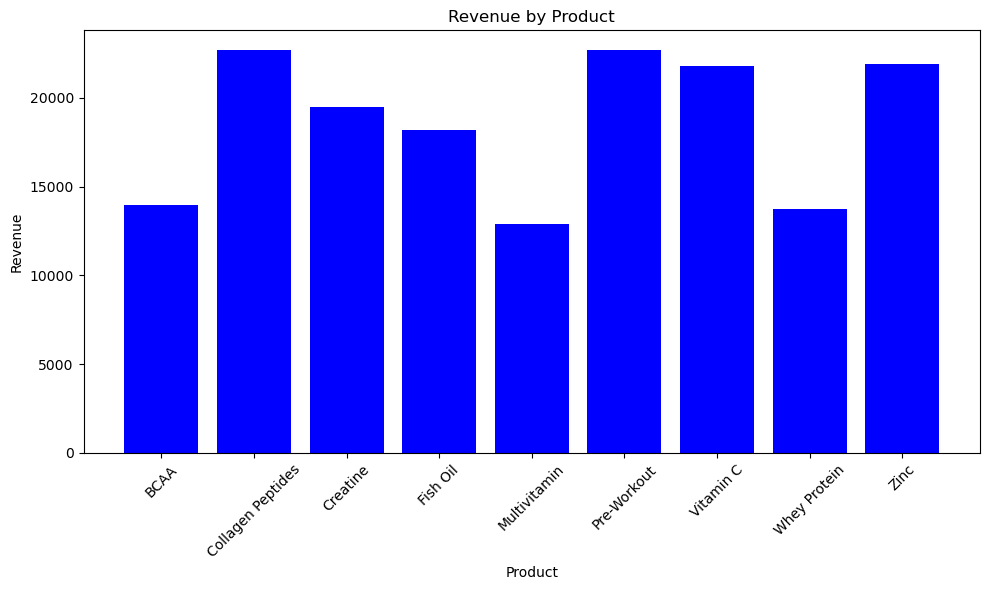

In [35]:
plt.figure(figsize=(10,6))
plt.bar(x["product"],x["revenue"],color="blue")
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
plt.savefig("sales_chart.png")

<Figure size 640x480 with 0 Axes>